In [1]:
import pandas as pd
import collections
import plotnine as p9
p9.theme_set(p9.theme_bw)

import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import calcutta
import scipy.sparse as sp
import scipy.io
import re
import calcutta
from importlib import reload
reload(calcutta)

<module 'calcutta' from '/gpfs/commons/home/daknowles/calcutta/calcutta/calcutta.py'>

## Check coverage per cell

In [27]:
salmon_dir = Path("/gpfs/commons/groups/knowles_lab/data/parse/original_SPLITseq_GSE110823/salmon_spliceu/quant_t2t")

cells_meta = pd.read_csv(salmon_dir / "featureDump.txt", sep = "\t")
cells_meta.shape # 192k cells


(192395, 9)

Text(0.5, 0, 'log10(deduped reads)')

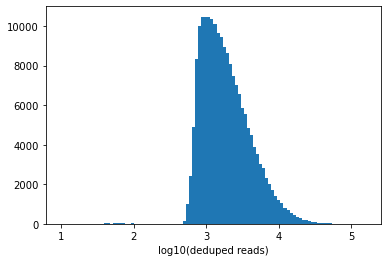

In [17]:
plt.hist(np.log10(cells_meta.DeduplicatedReads), 100)
plt.xlabel("log10(deduped reads)")

In [18]:
np.median(cells_meta.DeduplicatedReads) # went down from ~1600 with quant(knee) to 287 with quant_known & min_reads==100!? 

1650.906

## Check barcodes

Get barcodes, these are actually the same for each round

In [6]:
polydT_hex_pairs = pd.read_csv("splitseqv1_meta/oligo_hex_bc_mapping.txt", sep = "\t" )
polydT_hex_pairs.columns = ["polydT", "hex"]
polydT_hex_pairs.head()

,polydT,hex
0,AACGTGAT,GATAGACA
1,AAACATCG,GCCACATA
2,ATGCCTAA,GCGAGTAA
3,AGTGGTCA,GCTAACGA
4,ACCACTGT,GCTCGGTA


In [7]:
valid_bcs = polydT_hex_pairs.polydT.tolist() + polydT_hex_pairs.hex.tolist()

In [8]:
valid_counter = collections.Counter()
to_keep = np.zeros(cells_meta.shape[0], dtype=bool)
for i,bc in enumerate(cells_meta.CB):
    hit1 = bc[:8] in valid_bcs
    hit2 = bc[8:16] in valid_bcs
    hit3 = bc[16:] in valid_bcs
    to_keep[i] = hit1 and hit2 and hit3
    valid_counter[ (hit1,hit2,hit3)] += 1 

valid_counter # hell yeah, 188k valid barcodes. oh actually half of these need merging... 

Counter({(True, True, True): 188964,
         (True, False, False): 1225,
         (False, False, False): 663,
         (True, True, False): 1378,
         (True, False, True): 73,
         (False, True, True): 92})

In [10]:
valid_counter[(True,True,True)] / len(cells_meta) # 98% valid

0.982166896229112

In [11]:
cells_sub = cells_meta.iloc[to_keep,:]

## Read cells x genes count matrix

In [9]:
if False: 
    count_mat = scipy.io.mmread(salmon_dir / "alevin" / "quants_mat.mtx") # cells x genes
    scipy.sparse.save_npz(salmon_dir / "alevin" / "quants_mat.npz", count_mat)
else: 
    count_mat = scipy.sparse.load_npz(salmon_dir / "alevin" / "quants_mat.npz")

In [12]:
salmon_dir

PosixPath('/gpfs/commons/groups/knowles_lab/data/parse/original_SPLITseq_GSE110823/salmon_spliceu/quant')

In [10]:
count_sub = count_mat.tocsr()[to_keep,:] # only keep valid BCs

In [11]:
genes = [ g.strip() for g in open(salmon_dir / "alevin" / "quants_mat_cols.txt","r").readlines() ]

In [12]:
gene_sums = calcutta.sparse_sum(count_sub,0)

In [13]:
#is_precursor = np.array([ ("-I" in g) for g in genes ])
cleaner = lambda g: g.group(1) if g else "S"
align_type = np.array([ cleaner(re.search(r'-(.*)', g)) for g in genes ])
align_type

array(['S', 'S', 'S', ..., 'A', 'A', 'A'], dtype='<U1')

/gpfs/commons/home/daknowles/.conda/envs/asb/lib/python3.8/site-packages/pandas/core/arraylike.py:364: RuntimeWarning: divide by zero encountered in log10
/gpfs/commons/home/daknowles/.conda/envs/asb/lib/python3.8/site-packages/plotnine/layer.py:324: PlotnineWarning: stat_bin : Removed 73899 rows containing non-finite values.


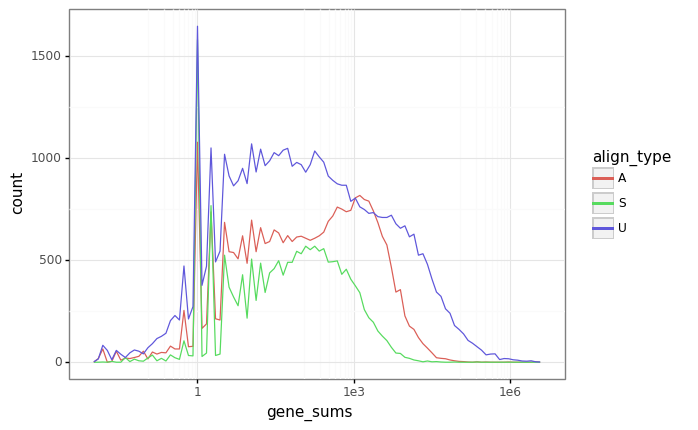

<ggplot: (8733041214428)>

In [14]:

to_plot = pd.DataFrame({"gene_sums" : gene_sums, "align_type" : align_type})
p9.ggplot(to_plot, p9.aes("gene_sums", color = "align_type")) + p9.scale_x_log10() + p9.geom_freqpoly(bins = 100)  

## Check correlation of U/S/A features

In [15]:
genes_np = np.array(genes)
genes_np[align_type == "A"] # check S and U: they are the same ordering. S, U, A. 

array(['ENSMUSG00000026315.14-A', 'ENSMUSG00000063558.5-A',
       'ENSMUSG00000001138.14-A', ..., 'ENSMUSG00002075613.1-A',
       'ENSMUSG00002076920.1-A', 'ENSMUSG00002076770.1-A'], dtype='<U23')

In [16]:
num_actual_genes = sum(align_type == "A")
num_actual_genes

56953

/gpfs/commons/home/daknowles/.conda/envs/asb/lib/python3.8/site-packages/pandas/core/arraylike.py:364: RuntimeWarning: divide by zero encountered in log10


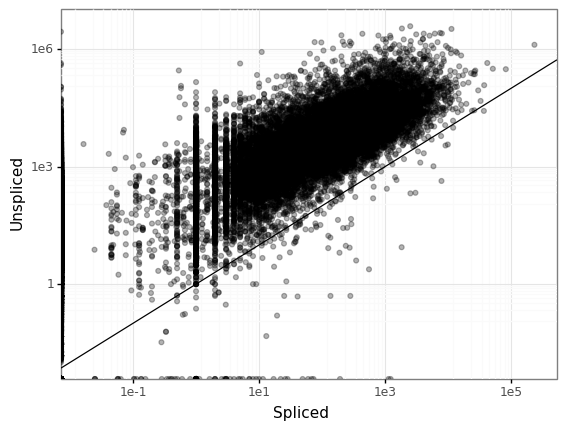

<ggplot: (8733041097418)>

In [19]:
gene_sum_df = pd.DataFrame({
    "Spliced" : gene_sums[:num_actual_genes], 
    "Unspliced" : gene_sums[num_actual_genes:2*num_actual_genes], 
    "Ambiguous" : gene_sums[2*num_actual_genes:]})
( p9.ggplot(gene_sum_df, p9.aes("Spliced","Unspliced")) + 
 p9.geom_point(alpha=0.3) + 
 p9.scale_x_log10() + 
 p9.scale_y_log10() +
 p9.geom_abline(intercept=0, slope = 1)
)

In [36]:
10 ** np.nanmean(np.log10(gene_sum_df.Unspliced + 0.1) - np.log10(gene_sum_df.Spliced+ 0.1))

62.26333125817546

In [37]:
10 ** np.nanmean(np.log10(gene_sum_df.Ambiguous + 0.1) - np.log10(gene_sum_df.Spliced+ 0.1))

5.365192329341847

In [38]:
10 ** np.nanmean(np.log10(gene_sum_df.Unspliced + 0.1) - np.log10(gene_sum_df.Ambiguous+ 0.1))

11.605051121403763

There is 12 times more U than A, and five times more A than S. I suppose S is just spliced reads, A is exonic (could be precursor!) including UTRs and U is intronic. If exons are 150bp and reads are ~70bp I would have though A ~= S coming from mature. 

In [117]:
genes_np[~is_precursor] # ah, really wanted genes here

array(['ENSMUST00000000514.11', 'ENSMUST00000001027.7',
       'ENSMUST00000001166.14', ..., 'ENSMUST00020183566.1',
       'ENSMUST00020183589.1', 'ENSMUST00020183724.1'], dtype='<U23')

/gpfs/commons/home/daknowles/.conda/envs/asb/lib/python3.8/site-packages/pandas/core/arraylike.py:364: RuntimeWarning: divide by zero encountered in log10


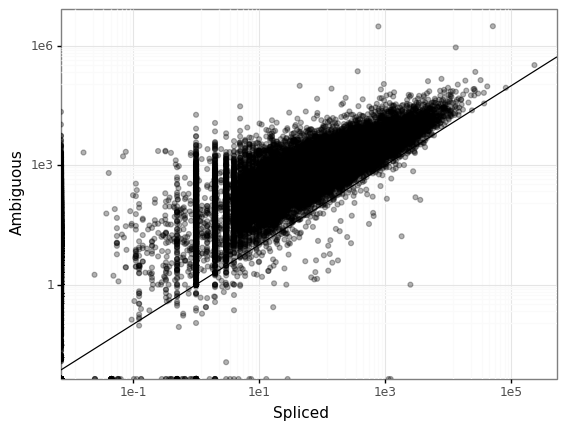

<ggplot: (8733041023160)>

In [21]:
( p9.ggplot(gene_sum_df, p9.aes("Spliced","Ambiguous")) + p9.geom_point(alpha=0.3) + p9.scale_x_log10() + p9.scale_y_log10() + 
 p9.geom_abline(intercept=0, slope = 1) )

Note: 32652 half cells have no pair


/gpfs/commons/home/daknowles/.conda/envs/asb/lib/python3.8/site-packages/pandas/core/arraylike.py:364: RuntimeWarning: divide by zero encountered in log10


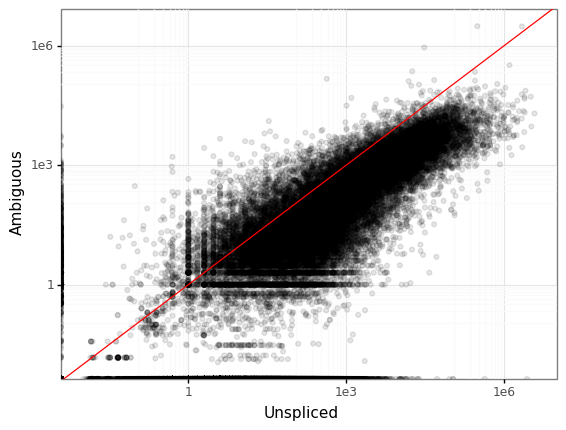

<ggplot: (8732747532538)>

In [28]:
( p9.ggplot(gene_sum_df, p9.aes("Unspliced","Ambiguous")) + 
 p9.geom_point(alpha=0.1) + 
 p9.scale_x_log10() + 
 p9.scale_y_log10() + p9.geom_abline(intercept=0, slope = 1, color="red")
)

## Combine USA features

In [166]:
count_mat_csr = count_sub.tocsr()
count_comb = count_mat_csr[:,align_type == "A"] + count_mat_csr[:,align_type == "U"] + count_mat_csr[:,align_type == "S"]
count_comb.shape

In [168]:
comb_sums = sparse_sum(count_comb,0)

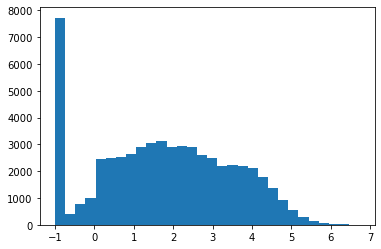

In [297]:
_ = plt.hist(np.log10(comb_sums + 0.1),30)

In [177]:
gene_to_keep = comb_sums >= 10000
np.sum(gene_to_keep)

6402

In [179]:
count_small = count_comb[:,gene_to_keep]

(array([8.0500e+02, 5.8840e+03, 1.6677e+04, 2.0149e+04, 2.0201e+04,
        1.9636e+04, 1.8297e+04, 1.6783e+04, 1.4779e+04, 1.2697e+04,
        1.0655e+04, 8.6370e+03, 6.7230e+03, 5.2890e+03, 3.8500e+03,
        2.6960e+03, 1.8940e+03, 1.2780e+03, 8.1800e+02, 5.1200e+02,
        2.9900e+02, 1.7900e+02, 1.0300e+02, 5.3000e+01, 3.7000e+01,
        2.1000e+01, 6.0000e+00, 2.0000e+00, 2.0000e+00, 2.0000e+00]),
 array([2.62545346, 2.71046859, 2.79548371, 2.88049883, 2.96551395,
        3.05052908, 3.1355442 , 3.22055932, 3.30557444, 3.39058957,
        3.47560469, 3.56061981, 3.64563493, 3.73065006, 3.81566518,
        3.9006803 , 3.98569542, 4.07071055, 4.15572567, 4.24074079,
        4.32575591, 4.41077104, 4.49578616, 4.58080128, 4.6658164 ,
        4.75083153, 4.83584665, 4.92086177, 5.00587689, 5.09089202,
        5.17590714]),
 <BarContainer object of 30 artists>)

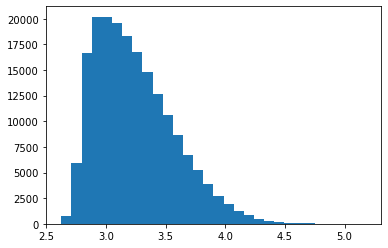

In [184]:
cell_sums = sparse_sum(count_small, 1)
plt.hist(np.log10(cell_sums),30)

## Merge polydT and rand hexamer data for the same cell

In [ ]:
new_BCs, cell_to_half_map = calcutta.make_cell_halfcell_matrix(cells_sub.CB.tolist(), polydT_hex_pairs)

In [26]:
import sys
!conda install --yes --prefix {sys.prefix} -c conda-forge scanpy python-igraph leidenalg

Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 4.10.3
  latest version: 22.9.0

Please update conda by running

    $ conda update -n base conda



## Package Plan ##

  environment location: /gpfs/commons/home/daknowles/.conda/envs/asb

  added / updated specs:
    - leidenalg
    - python-igraph
    - scanpy


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    arpack-3.7.0               |       hc6cf775_1         216 KB  conda-forge
    igraph-0.9.4               |       ha184e22_0         1.0 MB  conda-forge
    leidenalg-0.8.7            |   py38h709712a_0         139 KB  conda-forge
    python-igraph-0.9.1        |   py38h2af5540_0         1.2 MB  conda-forge
    texttable-1.6.4            |     pyhd8ed1ab_0          16 KB  conda-forge
    ------------------------------------------------------------
                                     

In [298]:
full_cell_small= cell_to_half_map @ count_small

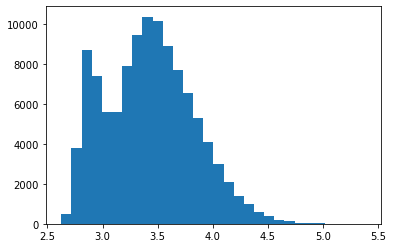

In [300]:
cell_sums = sparse_sum(full_cell_small, 1)
_ = plt.hist(np.log10(cell_sums),30) # presumably two peaks because of half vs full cells

In [302]:
rat = sp.diags(10000. / cell_sums) @ full_cell_small # normalize for coverage. ~82% sparse

In [ ]:
## TODO: basic (scanpy) steps: PCA, clustering, cell-type assignment. 

## Investigate ECs

In [14]:
num_genes, num_ec, ecs = calcutta.read_alevin_ec(salmon_dir / "alevin" / "gene_eqclass.txt.gz")

In [23]:
min([len(g) for _,g in ecs.items()]) # 1, good

1

## Old code working directly with rad file

In [ ]:
salmon_dir = Path("/gpfs/commons/groups/knowles_lab/data/parse/original_SPLITseq_GSE110823/salmon_joint/out_permit_knee")

# it seems the rad file is sorted by CB so probably could do this memory efficiently (read in cell data, then summarize)
new_ecs,cell_ec,transcripts = calcutta.read_rad(
    salmon_dir / "map.collated.txt.gz", 
    stranded = False)

np.all(np.array(list(new_ecs.values())) == np.arange(len(new_ecs)))

# is it worth recoding? probably easier from the sparse matrix? 

with open(salmon_dir / "transcripts.txt","w") as f: 
    f.writelines([g+"\n" for g  in transcripts])
    
with open(salmon_dir / "my.ec","w") as f: 
    for g in new_ecs.keys(): 
        f.write(",".join([str(h) for h in g]) + "\n")
        
nnz = sum( len(cell_ec[BC]) for BC in cell_ec )

indices = np.zeros((2,nnz), dtype=int) # cell then EC idx
umi_counts = np.zeros(nnz, dtype=int)

nz_idx = 0
for BC_idx,BC in enumerate(cell_ec): 
    nhere = len(cell_ec[BC])
    indices[0,nz_idx:nz_idx+nhere] = BC_idx
    indices[1,nz_idx:nz_idx+nhere] = list(cell_ec[BC].keys()) # EC idx
    umi_counts[nz_idx:nz_idx+nhere] = list(cell_ec[BC].values())
    nz_idx += nhere
    
cell_ec_sparse = sp.coo_matrix((umi_counts, indices))

sp.save_npz(salmon_dir / "cell_umi.npz", cell_ec_sparse)

In [278]:
is_sense # found about twice as many true as false, so I think it is stranded. 

Counter({True: 627892})

In [48]:
0.04 * 20000 / 60 # 13 minutes

13.333333333333334

The history saving thread hit an unexpected error (OperationalError('database is locked')).History will not be written to the database.
